<a href="https://colab.research.google.com/github/anjuchakku22-web/reimagined-broccoli/blob/main/internshiptask3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('tested.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [9]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [10]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [11]:
df = df.drop(columns=['Cabin'], errors='ignore')

In [12]:
df['FamilySize'] = df['SibSp'] + df['Parch']

In [13]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 20, 40, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'MidAge', 'Senior']
)

In [14]:
age_survival = df.groupby('AgeGroup')['Survived'].mean()
print(age_survival)

AgeGroup
Child     0.480000
Teen      0.454545
Adult     0.330882
MidAge    0.393939
Senior    0.363636
Name: Survived, dtype: float64


/tmp/ipykernel_4995/4094033240.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].mean()


In [15]:
embark_survival = df.groupby('Embarked')['Survived'].mean()
print(embark_survival)

Embarked
C    0.392157
Q    0.521739
S    0.325926
Name: Survived, dtype: float64


In [16]:
family_survival = df.groupby('FamilySize')['Survived'].mean()
print(family_survival)

FamilySize
0     0.268775
1     0.486486
2     0.526316
3     0.714286
4     0.285714
5     0.666667
6     0.250000
7     0.500000
10    0.500000
Name: Survived, dtype: float64


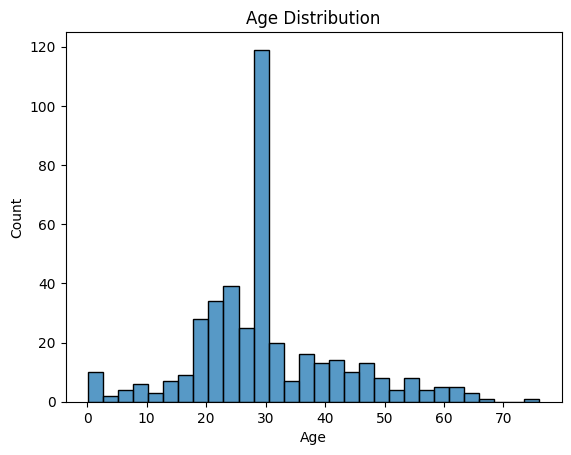

In [17]:
plt.figure()
sns.histplot(df['Age'], bins=30)
plt.title('Age Distribution')
plt.show()

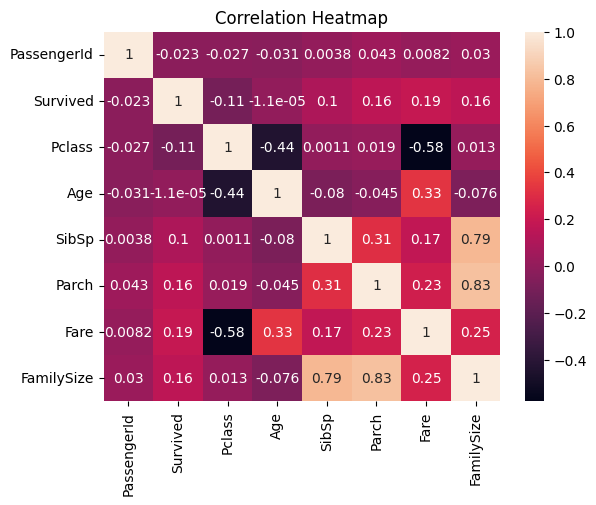

In [18]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()

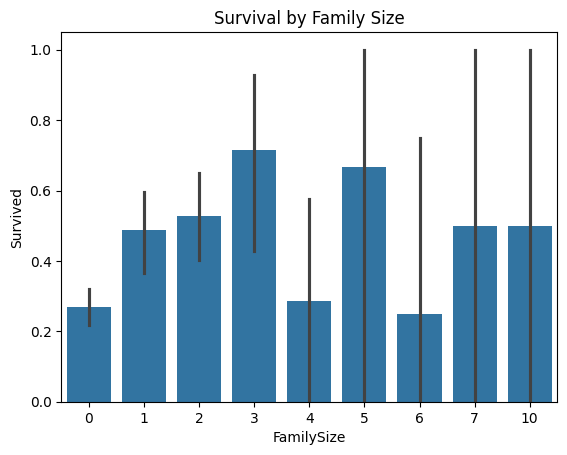

In [19]:
plt.figure()
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Survival by Family Size')
plt.show()

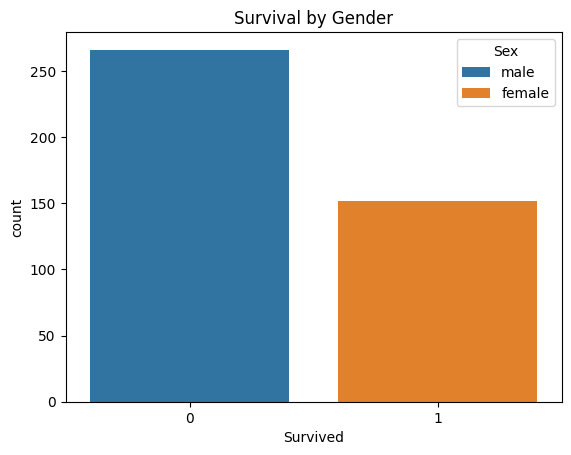

In [20]:
plt.figure()
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by Gender')
plt.show()